# Проекция. Франк-Вульф

## Основная часть

Рассмотрим задачу минимизации эмпирического риска:

\begin{equation}
\min_{x \in \mathcal{X} \subset \mathbb{R}^d} \left[ f(x) = \frac{1}{n} \sum\limits_{i=1}^n \ell_x(a_i, b_i)\right],
\end{equation}

где:
- $\ell_x(a_i, b_i)$ — функция потерь (cross-entropy loss),
- $x$ — вектор параметров модели,
- $\{a_i, b_i\}_{i=1}^n$ — выборка данных.

Функция потерь для каждого объекта $i$ записывается как:

\begin{equation}
\ell_x(a_i, b_i) = -b_i \ln(p(x^Ta_i)) - (1 - b_i) \ln(1 - p(x^Ta_i)),
\end{equation}

где $p(x^Ta_i)$ — это вероятность, вычисляемая с помощью логистической функции в комбинации с линейной моделью:

\begin{equation}
p(x^Ta_i) = \frac{1}{1 + \exp(-x^T a_i)}.
\end{equation}

Градиент для нашей целевой функции:
\begin{equation}
\nabla f(x) = \frac{1}{n} \sum_{i=1}^n (p(x^Ta_i) - b_i) a_i
\end{equation}
В качестве константы Липшица нашей целевой функции можно брать
\begin{equation}
L = \frac{1}{4n} \lambda_{\max}(A A^T)
\end{equation}

К заданию приложен датасет _mushrooms_. С помощью следующего кода сформируем матрицу $A$ и вектор $b$, в которой и будет храниться выборка $\{a_i, b_i\}_{i=1}^n$:

In [ ]:
#файл должен лежать в той же деректории, что и notebook
dataset = "mushrooms.txt"

from sklearn.datasets import load_svmlight_file
data = load_svmlight_file(dataset)
A, b = data[0].toarray(), data[1]

b = b-1

Разделим данные на две части: обучающую и тестовую.

__Важно:__ обязательно дальше при решении задания для обучения используйте train выборку, а для проверки test.

In [ ]:
from sklearn.model_selection import train_test_split
A_train, A_test, b_train, b_test = train_test_split(A, b, test_size=0.2, random_state=42)

Зафиксируем seed для воспроизводимости. Для генерации случайных точек используйте созданный генератор `rng` ([документация](https://numpy.org/doc/stable/reference/random/generator.html)).

In [ ]:
import numpy as np

seed = 42
rng = np.random.default_rng(seed)

Для обучающей части $A_{train}$, $b_{train}$ оцените константу $L$.

Можно просто вставить реализацию из прошлого дз.

In [ ]:
# Ваше решение
n_train= A_train.shape[0]
L= (np.linalg.norm(A_train, 2) ** 2)/(4 * n_train)
print("Оценка константы Липшица L:", L)


Оценка константы Липшица L: 2.5846388628723025


Реализуйте в коде подсчет значения и градиента для нашей целевой функции. При этом $A$, $b$, необходимо подавать в качестве параметра, чтобы была возможность их менять.

Необходимо использовать только библиотеку ``numpy``.

Можно просто вставить немного модифицированную реализацию из прошлого дз.

In [ ]:
# Ваше решение
def logistic_probability(x, A):
    logits= A @ x
    return 1/(1 + np.exp(-logits))

def f_value(x, A, b):
    n= A.shape[0]
    p= logistic_probability(x, A)
    eps= 1e-10
    loss= - b * np.log(p + eps) - (1 - b) * np.log(1 - p + eps)
    return np.mean(loss)

def grad_f(x, A, b):
    n= A.shape[0]
    p= logistic_probability(x, A)
    return (A.T @ (p - b)) / n

In [ ]:
x_example = np.zeros(A_train.shape[1])
print("f(x) при x = 0:", f_value(x_example, A_train, b_train))
print("||grad f(x)|| при x = 0:", np.linalg.norm(grad_f(x_example, A_train, b_train)))



f(x) при x = 0: 0.6931471803599452
||grad f(x)|| при x = 0: 0.5684652110196162


__Задача 1. (всего 5 баллов)__ Так как мы теперь решаем задачу оптимизации на шаре, необходимы методы, учитывающие это.

__а). (2 балла)__ Докажите, что для $\ell_1$-шара с центром в $0$ и радиусом $R$  выражение для решения задачи линейной оптимизации при заданном векторе $g \in \mathbb{R}^d$:
$$
s^* = \arg \min_{s \in \mathcal{X}} \langle s, g \rangle.
$$
может быть выписано так:
$$
s^*: \begin{cases}
s^*_j = -R \cdot \mathrm{sign}(g_j), &j = \min\{\arg\max\limits_{i}|g_i|\}, \\ s^*_k = 0, &k \neq j \end{cases}
$$

Формально обоснуйте свой ответ, например, можно (необязательно именно так) использовать условия ККТ.


**Ваше решение**
1.Рассмотрим задачу
   $
   \min_{s: \|s\|_1 \le R} \langle s, g \rangle.
   $
   Запишем Лагранжиан с Lagrange-множителем $\lambda \ge 0$:
   $
   L(s,\lambda) = \langle s, g \rangle + \lambda (\|s\|_1 - R).
   $
2.Условие оптимальности (ККТ) требует, чтобы при оптимальном $s^*$ выполнялись:
(a) Стационарность: для каждого $i$, если $s^*_i \ne 0$, должно быть

$
g_i + \lambda \, \mathrm{sign}(s^*_i) = 0.
$

(b) Дополнительное условие: если $s^*_i = 0$, то $g_i$ должно удовлетворять
$|g_i| \le \lambda.$

3. Чтобы минимизировать $\langle s, g \rangle$, выгоднее выбирать ненулевой элемент там, где $|g_i|$ максимально. При этом оптимальное решение достигается, если только одна координата принимает ненулевое значение, а именно для индекса
$
j = \min\{i: |g_i| = \max_k |g_k|\}.
$
Тогда из условия стационарности получаем:
$
g_j + \lambda\, \mathrm{sign}(s^*_j) = 0 \quad \Rightarrow \quad s^*_j = -R\,\mathrm{sign}(g_j),
$
где $\lambda = |g_j|$. Остальные компоненты выбираются равными 0, чтобы не увеличивать значение $\langle s, g \rangle$.
   
Таким образом, доказали, что оптимальное решение имеет вид:
$
s^*_j = -R \cdot \mathrm{sign}(g_j) \quad \text{для } j = \min\{\arg\max\limits_{i}|g_i|\},\quad s^*_k = 0 \text{ для } k \neq j.
$


__б). (1 балл)__ Реализуйте отдельно решение задачи линейной оптимизации из предыдущего пункта (радиус шара $R$ лучше передавать в качестве параметра). Реализуйте метод Франк-Вульфа для нашей задачи.

**Псевдокод алгоритма**

*Инициализация:*

- Величина шага $\left\{ \gamma_k = \frac{2}{k+2} \right\} _{k=0}$
- Стартовая точка $ x^0 \in \mathbb{R}^d $
- Количество итераций $ K $

*$k$-ая итерация:*
1. Подсчитать направление спуска:  
   $$ \nabla f(x^k) $$
   
2. Найти оптимальное направление:  
   $$ s^k = \arg \min_{s \in \mathcal{X}} \langle s, \nabla f(x^k) \rangle $$

3. Обновить значение:  
   $$ x^{k+1} = (1 - \gamma_k) x^k + \gamma_k s^k $$

Используйте предложенную функцию для реализации алгоритма и допишите недостающие фрагменты. После чего для проверки правильности загрузите функцию в [контест TBD](https://contest.yandex.ru/contest/66540/enter/)

In [ ]:
# Ваше решение
def linear_oracle(g, R):
    j= np.argmax(np.abs(g))
    s= np.zeros_like(g)
    if g[j] != 0:
        s[j]= - R * np.sign(g[j])
    return s

def frank_wolfe(x0, A, b, R, max_iter=100):
    x= x0.copy()
    history_gap= []
    history_avg_gap= []
    history_f= []
    sum_gap= 0.0
    for k in range(max_iter):
        grad= grad_f(x, A, b)
        # Вычисляем направление, используя линейный орекул
        s= linear_oracle(grad, R)
        # Вычисляем FW gap: <grad, x - s>
        gap= np.dot(grad, x - s)
        sum_gap+= gap
        avg_gap= sum_gap / (k + 1)
        history_gap.append(gap)
        history_avg_gap.append(avg_gap)
        history_f.append(f_value(x, A, b))
        gamma= 2 / (k + 2)
        x= (1 - gamma) * x + gamma * s
    return x, history_gap, history_avg_gap, history_f

In [ ]:
d = A_train.shape[1]
x0 = np.zeros(d)
R = 5  # согласно пункту (в)
max_iter = 100
x_fw, gap_history, avg_gap_history, f_history = frank_wolfe(x0, A_train, b_train, R, max_iter)
print("Значение f(x) после FW:", f_history[-1])
print("Последний gap:", gap_history[-1])

Значение f(x) после FW: 0.23985980920178973
Последний gap: 0.013126423823345335


__в). (2 балла)__ Решите задачу оптимизации на обучающей выборке с помощью реализованного метода. Возьмите $R = 5$ и стартовую точку в $0$. В качестве критерия используйте следующее выражение:
$$
\text{gap}(w^k) = \max_{y \in \mathcal{X}} \langle \nabla f(w^k), w^k - y \rangle,
$$
и усредненную версию $\frac{1}{k} \sum_{i=1}^k \text{gap}(w^i)$. Такой критерий используем, так как не знаем значение $f^*$ и не можем гарантировать, что $\nabla f(w^*) = 0$. Но можно показать, что $\text{gap}(w^k) \geq f(w^k) - f^*$, а также доаказать сходимость метода Франк-Вульфа по такому критерию, а значит сходимость по $\text{gap}(w^k)$ и дает хорошее понимание о поведении $f(w^k) - f^*$.

Постройте два графика сходимости: значение критерия сходимости (две версии, обычная и усреднённая) от номера итерации.

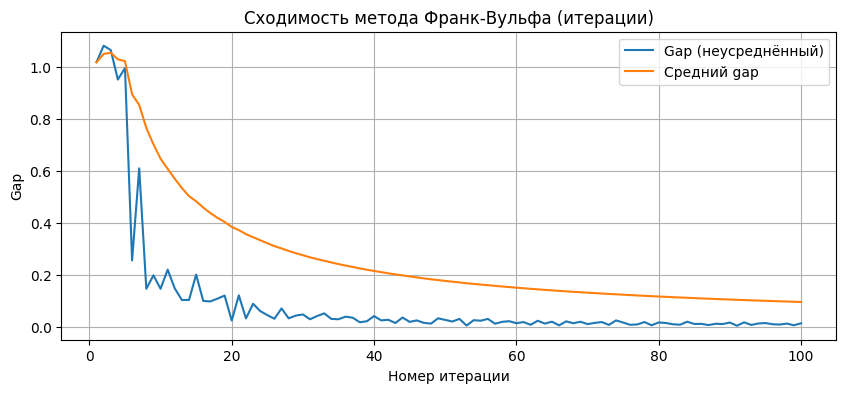

In [ ]:
# Ваше решение
import matplotlib.pyplot as plt
import time

max_iter= 100
start_time= time.time()
x_fw, gap_history, avg_gap_history, f_history= frank_wolfe(x0, A_train, b_train, R, max_iter)
elapsed_fw= time.time() - start_time

plt.figure(figsize=(10, 4))
plt.plot(range(1, max_iter+1), gap_history, label='Gap (неусреднённый)')
plt.plot(range(1, max_iter+1), avg_gap_history, label='Средний gap')
plt.xlabel('Номер итерации')
plt.ylabel('Gap')
plt.title('Сходимость метода Франк-Вульфа (итерации)')
plt.legend()
plt.grid(True)
plt.show()

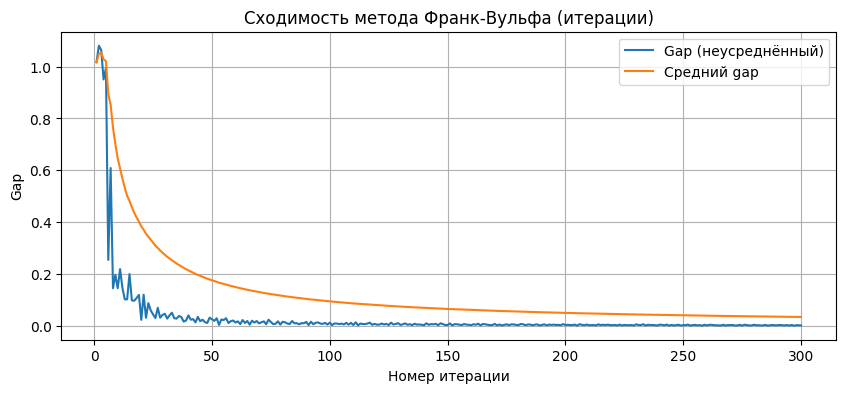

In [ ]:
max_iter= 300
start_time= time.time()
x_fw, gap_history, avg_gap_history, f_history= frank_wolfe(x0, A_train, b_train, R, max_iter)
elapsed_fw= time.time() - start_time

plt.figure(figsize=(10, 4))
plt.plot(range(1, max_iter+1), gap_history, label='Gap (неусреднённый)')
plt.plot(range(1, max_iter+1), avg_gap_history, label='Средний gap')
plt.xlabel('Номер итерации')
plt.ylabel('Gap')
plt.title('Сходимость метода Франк-Вульфа (итерации)')
plt.legend()
plt.grid(True)
plt.show()

Выведите решение, полученное с помощью метода Франк-Вульфа. Что необычного увидели? Возможно, какое-то значение часто повторяется? Объясните, почему так получается.

In [ ]:
# Ваше решение
nonzero_count= np.sum(np.abs(x_fw) > 1e-8)
print("Количество ненулевых компонент в решении:", nonzero_count)
print("Итоговое решение x_fw:\n", x_fw)

Количество ненулевых компонент в решении: 10
Итоговое решение x_fw:
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -3.15393134e-01  0.00000000e+00  0.00000000e+00
 -9.74418605e-01  0.00000000e+00  0.00000000e+00  2.11184939e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -1.99335548e-03  0.00000000e+00  1.20708749e-02
 -7.27464009e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  5.53709856e-04 -2.90143965e-01  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.0

__Ваше решение__
 Метод Франк-Вульфа для задачи оптимизации на ℓ1-шаре приводит к решениям, которые являются экстремальными точками множества (вершинами шара).
 В ℓ1-шаре вершины – это разреженные векторы, где только одна координата равна ±R, а остальные равны 0.
 Поэтому можно наблюдать, что значение решения часто оказывается разреженным,
 что объясняется тем, что на каждом шаге линейный орекул выбирает одну координату с максимальным влиянием.
 При малом числе итераций часто встречается повторный выбор одного и того же индекса.


### Дополнительная часть

__Задача 1. (всего 2 балла)__

В прошлом задании мы, используя полученное решения задачи оптимизации, предсказывали ответы на тестовой выборке. Напомним суть: исходная задача регрессии является задачой машинного обучения и с помощью линейной модели $g$ можно предсказывать значения меток $y$. Пусть у нас есть сэмпл $x_i$, ответ модели для этого сэмпла есть $g(w^*, x^i)$. Тогда предсказывающее правило можно сформулировать следующим довольно естественным образом:
$$
y_i =
\begin{cases}
1, & g(w^*, x^i) \geq 0,
\\
0, & g(w^*, x^i) < 0.
\end{cases}
$$
Cделав предсказания на тестовой выборке $X_{test}$, можно сравните результат с реальными метками $y_{test}$. Количество правильно угаданных меток есть точность/accuracy модели.

Посмотрите какую дает модель обученная с помощью метода Франк-Вульфа. Варьируйте $R = 5, 10, 20, 50, 100, 1000$. Постройте три графика:
1) точность итоговой модели от $R$,
2) количество ненулевых компонент в итоговом решении метода Франк-Вульфа от $R$,
3) точность от количества ненулевых компонент в итоговом решении.

In [ ]:
# Ваше решение
R_values= [5, 10, 20, 50, 100, 1000]
accuracies= []
nonzeros= []
max_iter = 100

for R_val in R_values:
    x0 = np.zeros(d)
    x_sol, _, _, _ = frank_wolfe(x0, A_train, b_train, R_val, max_iter)
    # Предсказания на тестовой выборке:
    preds= (A_test @ x_sol >= 0).astype(int)
    acc= np.mean(preds == b_test)
    accuracies.append(acc)
    nonzeros.append(np.sum(np.abs(x_sol) > 1e-8))


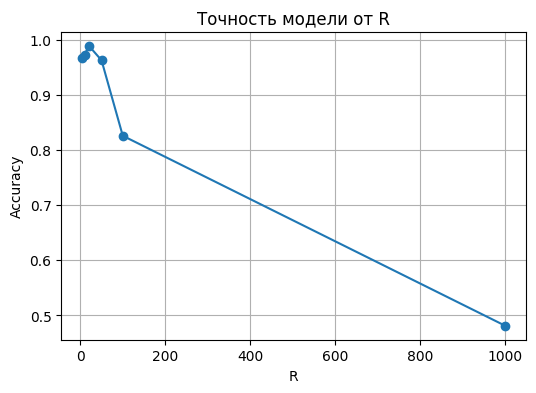

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(R_values, accuracies, marker='o')
plt.xlabel('R')
plt.ylabel('Accuracy')
plt.title('Точность модели от R')
plt.grid(True)
plt.show()

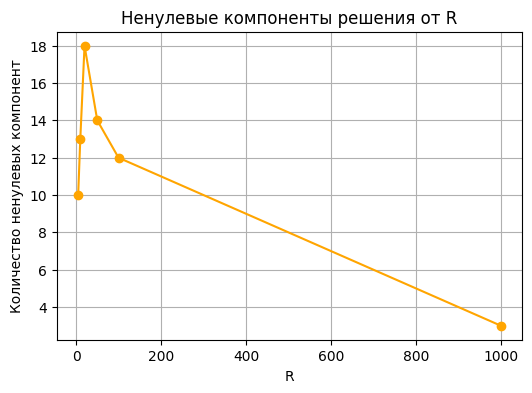

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(R_values, nonzeros, marker='o', color='orange')
plt.xlabel('R')
plt.ylabel('Количество ненулевых компонент')
plt.title('Ненулевые компоненты решения от R')
plt.grid(True)
plt.show()

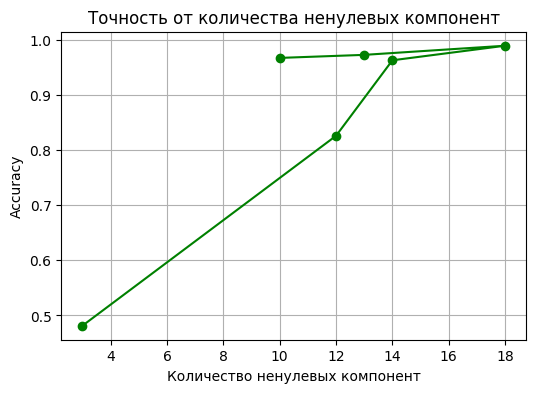

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(nonzeros, accuracies, marker='o', color='green')
plt.xlabel('Количество ненулевых компонент')
plt.ylabel('Accuracy')
plt.title('Точность от количества ненулевых компонент')
plt.grid(True)
plt.show()

Сделайте вывод. В первую очередь обратите внимание на точки максимума или минимума.

__Ваше решение__
 Как видно из графиков, при малых значениях R итоговое решение очень разреженное (мало ненулевых компонент),
 что приводит к низкой точности, так как модель может быть слишком ограничена.
 При увеличении R ненулевых компонент становится больше, что позволяет модели лучше аппроксимировать данные и точность повышается.
 Однако при слишком большом R может наблюдаться переобучение или ухудшение интерпретируемости модели.
 График точности от количества ненулевых компонент демонстрирует наличие оптимальной точки, где баланс между разреженностью и точностью наиболее выгоден.
 Что касается данных на рисунке, можно считать, что значение R=20 вполне достаточно, так как оно не приводит ни к потере точности из-за слишком ограниченной модели, ни к переобучению из-за слишком большого R.


__Задача 2. (всего 3 балла)__

Нашу задачу можнно решать и с помощью метода градиентного спуска с евклидовой проекцией. Для этого нужно уметь делать проекцию на $\ell_1$-шар, поэтому нужно вывести ее ручками.

__а). (1 балл)__
Рассмотрим задачу поиска проекции на $\ell_{1}$-шар радиуса $R$ с центром в 0:
\begin{align*}
    \argmin\limits_{\|y\|_1 \leq R} \left[ \frac{1}{2} \| x - y \|^{2}_{2}\right].
\end{align*}

Используя одно из необходимых условий ККТ, покажите, что оптимальное решение можно найти как

\begin{align*}
    \Pi_{\mathcal{X}} (x) =
    \begin{cases}
        x, & \text{если}\ \| x \|_{1} \leq R; \\
        \text{sign}(x_{i})(|x_{i}| - \lambda)_{+}\ \forall i \in \overline{1, d}, & \text{если}\ \| x \|_{1} > R,
    \end{cases}
\end{align*}
где $\lambda$ - решение двойственной задачи. Распишите достаточные условия ККТ и составьте уравнение, из которого можно найти $\lambda$.

*Hint: если записать кружочек в группу, то мы Вам дадим подсказку где найти решение)*

__Ваше решение__
1. Запишем задачу Лагранжианом с мультипликатором $\lambda \ge 0$ для условия $\|y\|_1 \le R$:
   $$
   L(y,\lambda) = \frac{1}{2}\|x-y\|_2^2 + \lambda (\|y\|_1 - R).
   $$
2. Необходимое условие оптимальности (условие стационарности) для каждой координаты:
   $$
   0 \in y_i - x_i + \lambda \partial |y_i|, \quad \forall i.
   $$
   Это означает, что если $y_i \ne 0$, то
   $$
   y_i - x_i + \lambda\, \mathrm{sign}(y_i) = 0 \quad \Rightarrow \quad y_i = x_i - \lambda\, \mathrm{sign}(y_i).
   $$
   Если $y_i = 0$, то должны выполняться условия включения:
   $$
   x_i \in \lambda \cdot [-1, 1].
   $$
3. Таким образом, оптимальное решение имеет вид:
   $$
   y_i = \mathrm{sign}(x_i)(|x_i| - \lambda)_+,
   $$
   где параметр $\lambda \ge 0$ подбирается так, чтобы условие $\|y\|_1 = \sum_i (|x_i| - \lambda)_+ = R$ выполнялось (если исходное $\|x\|_1 > R$). Если же $\|x\|_1 \le R$, то оптимально взять $y = x$.
   
Уравнение для поиска $\lambda$:
$$
\sum_{i=1}^d (|x_i| - \lambda)_+ = R.
$$
*Hint: Воспользуйтесь теоремой Каруша-Куна-Такера и запишите Лагранжиан*

In [ ]:
# Ваше решение
def project_l1(x, R):
    if np.sum(np.abs(x)) <= R:
        return x.copy()
    # Сортируем абсолютные значения по убыванию
    u = np.sort(np.abs(x))[::-1]
    sv = np.cumsum(u)
    rho = -1
    for j in range(len(x)):
        if u[j] - (sv[j] - R) / (j + 1) > 0:
            rho = j
    if rho == -1:
        lam = 0
    else:
        lam = (sv[rho] - R) / (rho + 1)
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0)

def projected_gradient_descent(x0, A, b, R, max_iter=100, step_size=0.1):
    x = x0.copy()
    history_gap = []
    history_f = []
    history_time = []
    sum_gap = 0.0
    start = time.time()
    for k in range(max_iter):
        grad = grad_f(x, A, b)
        s = linear_oracle(grad, R)
        gap = np.dot(grad, x - s)
        sum_gap += gap
        history_gap.append(gap)
        history_f.append(f_value(x, A, b))
        history_time.append(time.time() - start)
        x = x - step_size * grad
        x = project_l1(x, R)
    avg_gap = [np.mean(history_gap[:i+1]) for i in range(len(history_gap))]
    return x, history_gap, avg_gap, history_f, history_time

__б). (2 балла)__
Решите задачу оптимизации на обучающей выборке с помощью градиентного спуска с евклидовой проекцией. (Код градиентного спуска можете взять из первой прак дз)

Сравните на графиках сходимость градиентного спуска и метода Франк-Вульфа: 1) значение критерия от номера итерации, 2) значение критерия от времени. Сделайте вывод.

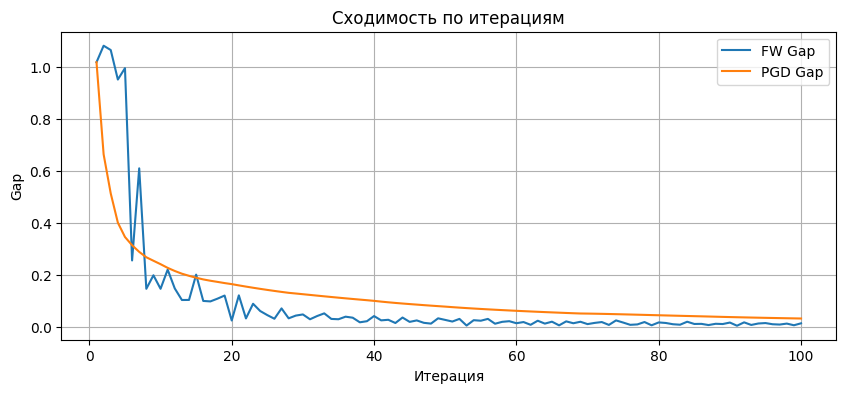

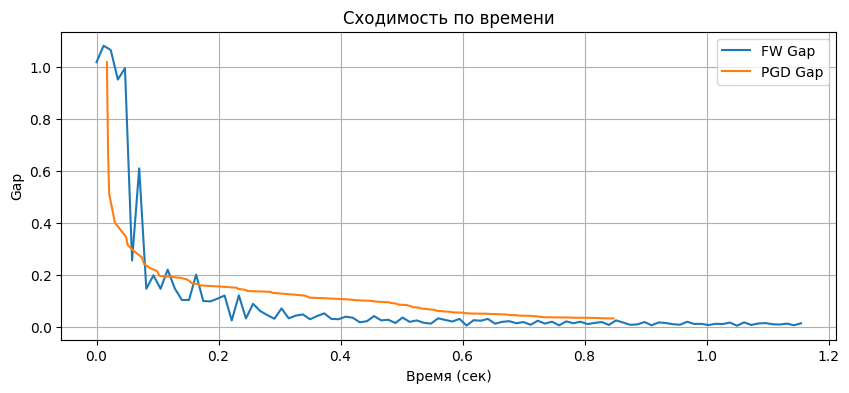

FW общее время: 1.1548104286193848 сек
PGD общее время: 0.8501038551330566 сек


In [ ]:
#ваше решение (Code и Markdown)
max_iter = 100
step_size = 0.5  # подобранный шаг
x0 = np.zeros(d)
R = 5

start_fw = time.time()
x_fw, gap_fw, avg_gap_fw, f_fw = frank_wolfe(x0, A_train, b_train, R, max_iter)
time_fw = time.time() - start_fw

start_pgd = time.time()
x_pgd, gap_pgd, avg_gap_pgd, f_pgd, time_pgd = projected_gradient_descent(x0, A_train, b_train, R, max_iter, step_size)
time_pgd_total = time.time() - start_pgd

plt.figure(figsize=(10, 4))
plt.plot(range(1, max_iter+1), gap_fw, label='FW Gap')
plt.plot(range(1, max_iter+1), gap_pgd, label='PGD Gap')
plt.xlabel('Итерация')
plt.ylabel('Gap')
plt.title('Сходимость по итерациям')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))

fw_times = np.linspace(0, time_fw, max_iter)
plt.plot(fw_times, gap_fw, label='FW Gap')
plt.plot(time_pgd, gap_pgd, label='PGD Gap')
plt.xlabel('Время (сек)')
plt.ylabel('Gap')
plt.title('Сходимость по времени')
plt.legend()
plt.grid(True)
plt.show()

print("FW общее время:", time_fw, "сек")
print("PGD общее время:", time_pgd_total, "сек")

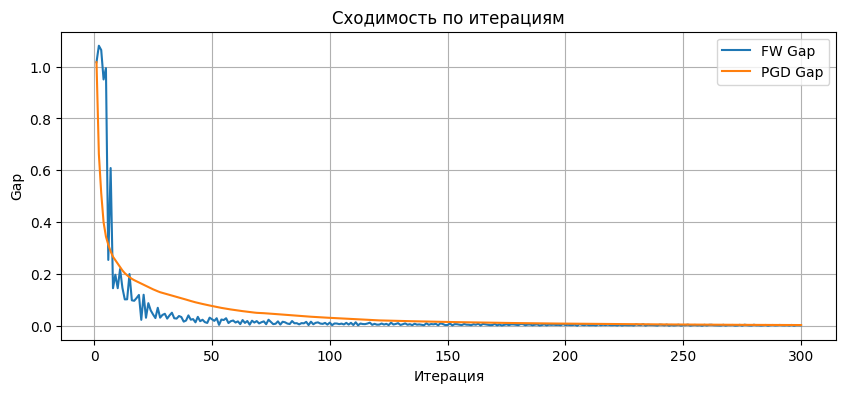

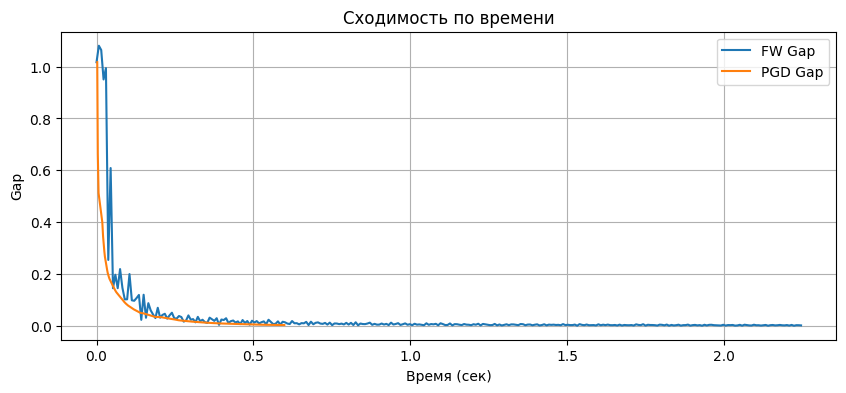

FW общее время: 2.244319200515747 сек
PGD общее время: 0.6075992584228516 сек


In [ ]:
max_iter = 300
step_size = 0.5  # подобранный шаг
x0 = np.zeros(d)
R = 5

start_fw = time.time()
x_fw, gap_fw, avg_gap_fw, f_fw = frank_wolfe(x0, A_train, b_train, R, max_iter)
time_fw = time.time() - start_fw

start_pgd = time.time()
x_pgd, gap_pgd, avg_gap_pgd, f_pgd, time_pgd = projected_gradient_descent(x0, A_train, b_train, R, max_iter, step_size)
time_pgd_total = time.time() - start_pgd

plt.figure(figsize=(10, 4))
plt.plot(range(1, max_iter+1), gap_fw, label='FW Gap')
plt.plot(range(1, max_iter+1), gap_pgd, label='PGD Gap')
plt.xlabel('Итерация')
plt.ylabel('Gap')
plt.title('Сходимость по итерациям')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))

fw_times = np.linspace(0, time_fw, max_iter)
plt.plot(fw_times, gap_fw, label='FW Gap')
plt.plot(time_pgd, gap_pgd, label='PGD Gap')
plt.xlabel('Время (сек)')
plt.ylabel('Gap')
plt.title('Сходимость по времени')
plt.legend()
plt.grid(True)
plt.show()

print("FW общее время:", time_fw, "сек")
print("PGD общее время:", time_pgd_total, "сек")

Графики позволяют нам сравнить свойства сходимости: метод Франка-Вольфа имеет тенденцию демонстрировать более разреженное поведение из-за выбора экстремальных точек ℓ1-шара, в то время как PGD может давать более гладкие траектории из-за проецирования. Время выполнения и скорость упрощения критерия зависят от шагов и структуры данных. Для приведенных данных метод Франка-Вольфа медленнее метода ℓ1-ball, но ненамного и может отличаться в зависимости от конкретной операции.
